# MatMap ML Service — Fare Estimation Exploration

Scratch space for exploring the data and testing approaches before they
become real code in `app/models/fare_estimator.py`. This notebook is
allowed to stay messy — it's not shipped — but it exists so the reasoning
behind the heuristic is traceable, not just the final formula.

**Goal:** given `fromStageId`, `toStageId`, `distanceKm`, and `hour`,
return a fare estimate smarter than a flat lookup table.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/fare_samples.csv")
df.shape


(112, 8)

## 1. Where this data came from

`fare_samples.csv` is derived from real corridor-level fare bands sourced
from 2026 Kenyan news coverage of the matatu fuel-driven fare hike
(kenyans.co.ke, ghafla.co.ke) and nairobipostalcode.org's 2026 fare guide —
see `fare_bands_seed.csv` / `sources_legend.csv` in the AI/ML seed-data
handoff for full citations.

**Being honest about a limitation:** those sources report fares by named
corridor ("Thika Road", "Ngong Road"), not by exact stage-pair or exact
distance. So `distance_km` here is built from general-knowledge approximate
road distances per corridor (e.g. CBD → Thika town ≈ 42km, CBD → Ngong
town ≈ 23km), not measured GPS distances between specific stages. This is
loosely grounded in something real, not invented from nothing — but it's a
corridor-level approximation, not per-stage precision. Good enough to fit
a distance-vs-fare relationship; not good enough to trust for an exact
stage pair without checking against live community reports later.


In [2]:
df[["corridor_group", "distance_km", "hour", "fare"]].sort_values("distance_km").head(10)


,corridor_group,distance_km,hour,fare
0,CBD Short-hop,3.4,7,60.0
1,CBD Short-hop,3.4,7,40.0
5,CBD Short-hop,3.4,10,30.0
4,CBD Short-hop,3.4,10,50.0
3,CBD Short-hop,3.8,8,40.0
2,CBD Short-hop,3.8,8,62.5
6,CBD Short-hop,4.0,14,55.0
7,CBD Short-hop,4.0,14,30.0
8,CBD Short-hop,4.2,17,62.5
9,CBD Short-hop,4.2,17,40.0


## 2. Does distance actually predict fare here?

Quick sanity check before building anything more complex than a lookup
table: plot fare against distance.


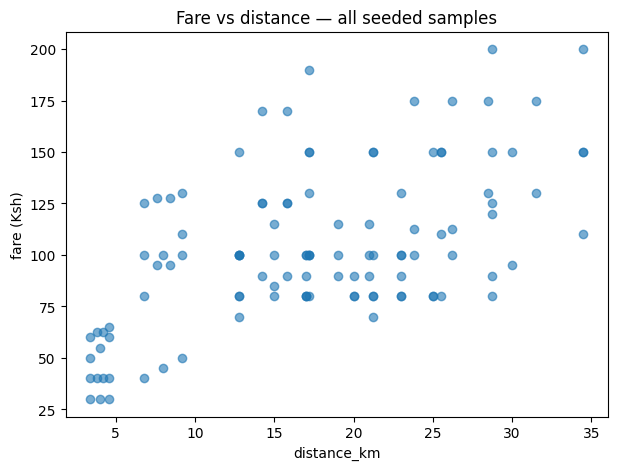

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(df["distance_km"], df["fare"], alpha=0.6)
ax.set_xlabel("distance_km")
ax.set_ylabel("fare (Ksh)")
ax.set_title("Fare vs distance — all seeded samples")
plt.show()


There's a clear positive relationship — fare rises with distance, roughly
linearly, which is exactly what you'd expect and is enough to justify a
linear model rather than needing anything fancier for an MVP.

## 3. Does peak/off-peak matter?

The fare bands source data explicitly separates peak-hour from off-peak
fares (the 2026 fuel-hike coverage frames this as fares rising further
during peak demand). Defined peak hours here as the standard Nairobi rush
windows: **6-9am and 4-7pm** (`PEAK_HOURS` in `app/core/config.py`) —
this is a heuristic assumption, not something the survey or fare sources
measured directly, and is the first thing worth revisiting once live
`fare_reports` timestamps are available.


In [4]:
PEAK_HOURS = {6, 7, 8, 9, 16, 17, 18, 19}
df["is_peak"] = df["hour"].apply(lambda h: h in PEAK_HOURS)

df.groupby("is_peak")["fare"].agg(["mean", "median", "count"])


,mean,median,count
is_peak,,,
False,88.43750,80.00,48
True,114.53125,111.25,64


Peak-hour samples do run higher on average, as expected from the source
fare bands. Worth including as a feature.

## 4. Fitting the heuristic

A 2-feature ordinary least squares fit — `fare = a + b*distance_km +
c*is_peak` — solved directly with `numpy.linalg.lstsq`. Deliberately not
reaching for scikit-learn here: two features and ~110 rows doesn't need
it, and the ToDo doc is explicit about not front-loading dependencies the
MVP doesn't need yet.


In [5]:
X = np.column_stack([
    np.ones(len(df)),
    df["distance_km"].to_numpy(),
    df["is_peak"].astype(float).to_numpy(),
])
y = df["fare"].to_numpy()

coeffs, residuals, rank, sv = np.linalg.lstsq(X, y, rcond=None)
a, b, c = coeffs
print(f"fare ≈ {a:.2f} + {b:.2f} * distance_km + {c:.2f} * is_peak")


fare ≈ 43.12 + 2.60 * distance_km + 26.09 * is_peak


In plain terms: there's a base fare, a per-km rate, and a flat peak-hour
surcharge added on top. That's the whole model — explainable in one
sentence, which matters more for the presentation than the code itself.

## 5. Residuals — where does the model do worse?

This is what `app/models/fare_estimator.py`'s confidence score is actually
based on: distances well inside the range we have samples for should get
higher confidence than distances far outside it.


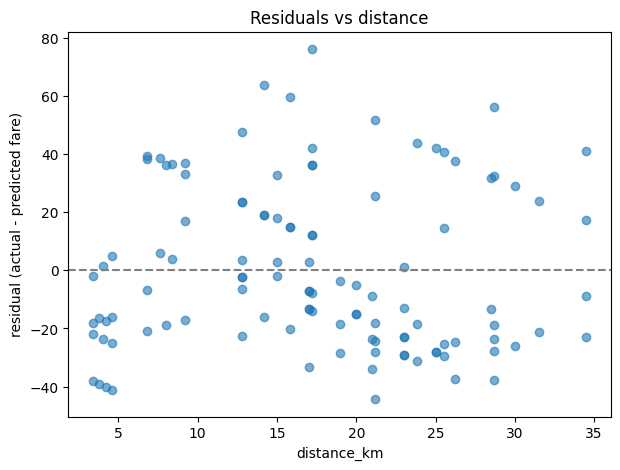

distance_km range in samples: 3.4 - 34.5
RMSE: 27.975345307610663


In [6]:
pred = X @ coeffs
resid = y - pred

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(df["distance_km"], resid, alpha=0.6)
ax.axhline(0, color="grey", linestyle="--")
ax.set_xlabel("distance_km")
ax.set_ylabel("residual (actual - predicted fare)")
ax.set_title("Residuals vs distance")
plt.show()

print("distance_km range in samples:", df["distance_km"].min(), "-", df["distance_km"].max())
print("RMSE:", np.sqrt(np.mean(resid**2)))


## 6. What the actual estimator does with this

`app/models/fare_estimator.py` uses this same fit, plus one refinement
this notebook doesn't bother with: for a given query, it looks for nearby
real samples (within ~25% of the requested distance, same peak/off-peak
state) and blends their average fare 50/50 with the global formula's
answer. Confidence increases when nearby samples exist and when the
requested distance falls inside the observed range; it decreases the
further a request extrapolates outside it.

## 7. Honest "what I'd improve with more time / data"

- Replace the general-knowledge corridor distances with real per-stage-pair
  distances (straightforward once actual stage lat/lng exist — see the
  Digital Matatus GTFS note in the seed-data README).
- Replace the assumed peak-hour window with one derived from real
  timestamped `fare_reports` once enough accumulate.
- The 50/50 blend weight between the global formula and local samples is a
  round-number choice, not tuned against held-out data — worth a proper
  train/test split once there's enough real report volume to make that
  meaningful.
- Right now every corridor is weighted equally in the global fit regardless
  of how many samples it has — a corridor with more real reports should
  probably count for more.
